## Las ciudades mas grandes tendran mayor indice de pobreza

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
poblacion = pd.read_csv('Base_urbanos_CPV24.csv',sep=';')
poblacion.head(5)

,CONTENEDOR_COMUNAL,COD_REGION,REGION,PROVINCIA,CUT,COMUNA,AREA_C,COD_LOCALIDAD,LOCALIDAD,COD_ENTIDAD,...,n_fuente_elect_diesel,n_fuente_elect_solar,n_fuente_elect_eolica,n_fuente_elect_otro,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro
0,0,1,TARAPACÁ,IQUIQUE,1101,IQUIQUE,1,9.0,IQUIQUE - ALTO HOSPICIO,1.0,...,72,45,3,39,51,62890,49,83,10,181
1,0,1,TARAPACÁ,IQUIQUE,1107,ALTO HOSPICIO,1,1.0,IQUIQUE - ALTO HOSPICIO,1.0,...,243,468,6,628,270,37270,178,656,7,718
2,0,1,TARAPACÁ,IQUIQUE,1107,ALTO HOSPICIO,1,2.0,ALTO MOLLE,2.0,...,48,342,0,22,116,481,92,18,0,60
3,0,1,TARAPACÁ,DEL TAMARUGAL,1401,POZO ALMONTE,1,12.0,LA TIRANA,2.0,...,8,49,0,7,18,578,21,44,0,27
4,0,1,TARAPACÁ,DEL TAMARUGAL,1401,POZO ALMONTE,1,21.0,POZO ALMONTE,1.0,...,41,178,0,12,29,3021,10,21,1,10


In [4]:
poblacion = poblacion.groupby('COMUNA')["n_per"].sum().to_frame('poblacion_total')
poblacion.index = [i.lower() for i in poblacion.index]
poblacion.index.name = 'comuna'
poblacion

,poblacion_total
comuna,
algarrobo,11136
alhué,4114
alto hospicio,139338
ancud,28015
andacollo,9629
...,...
yumbel,13025
yungay,13694
zapallar,4961


In [15]:
pobreza = pd.read_excel('Estimaciones_Indice_Pobreza_Multidimensional_Comunas_2022.xlsx',header=2,index_col=0)

pobreza = pobreza.groupby('Nombre comuna')["Número de personas en situación de pobreza multidimensional (**)"].sum().to_frame('pobreza_multidimensional')
pobreza.index.name = 'comuna'
pobreza.index = [i.lower() for i in pobreza.index]
pobreza

,pobreza_multidimensional
algarrobo,3079.295721
alhué,2238.877109
alto biobío,2639.780468
alto del carmen,1606.933028
alto hospicio,45162.442981
...,...
yumbel,3573.302203
yungay,2408.391058
zapallar,2193.841147
ñiquén,2211.644597


,poblacion_total,pobreza_multidimensional
comuna,,
algarrobo,11136,3079.295721
alhué,4114,2238.877109
alto hospicio,139338,45162.442981
ancud,28015,9752.400251
andacollo,9629,2287.331837
...,...,...
yumbel,13025,3573.302203
yungay,13694,2408.391058
zapallar,4961,2193.841147


In [18]:
# Crear dataframe unido y calcular tasa de pobreza
df = pd.merge(poblacion, pobreza, left_on='comuna', right_index=True, how='inner')
df['tasa_pobreza'] = (df['pobreza_multidimensional'] / df['poblacion_total']) * 100
df = df.sort_values('poblacion_total', ascending=False)
df.head(10)

,poblacion_total,pobreza_multidimensional,tasa_pobreza
comuna,,,
puente alto,568068,125234.776994,22.045737
maipú,501023,86975.679408,17.359618
santiago,438856,87355.062804,19.905177
antofagasta,398158,73102.886971,18.360271
la florida,374713,53467.236145,14.268850
viña del mar,334574,54770.753576,16.370296
san bernardo,301997,64276.113290,21.283693
las condes,296134,15049.324294,5.081931
valparaíso,283294,60901.116600,21.497496


## Gráfico 1 — Dispersión: Población vs Pobreza

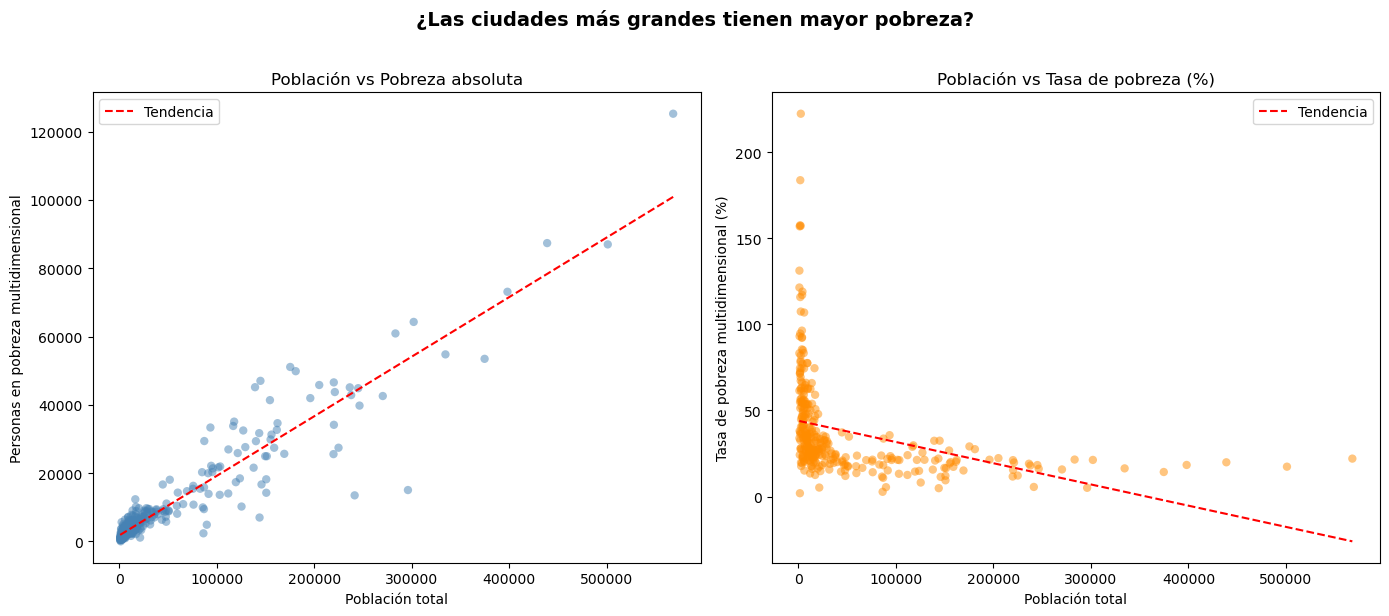

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel izquierdo: pobreza absoluta ---
axes[0].scatter(df['poblacion_total'], df['pobreza_multidimensional'],
                alpha=0.5, color='steelblue', edgecolors='none')
z0 = np.polyfit(df['poblacion_total'], df['pobreza_multidimensional'], 1)
x_line = np.linspace(df['poblacion_total'].min(), df['poblacion_total'].max(), 200)
axes[0].plot(x_line, np.poly1d(z0)(x_line), 'r--', linewidth=1.5, label='Tendencia')
axes[0].set_xlabel('Población total')
axes[0].set_ylabel('Personas en pobreza multidimensional')
axes[0].set_title('Población vs Pobreza absoluta')
axes[0].legend()

# --- Panel derecho: tasa de pobreza ---
axes[1].scatter(df['poblacion_total'], df['tasa_pobreza'],
                alpha=0.5, color='darkorange', edgecolors='none')
z1 = np.polyfit(df['poblacion_total'], df['tasa_pobreza'], 1)
axes[1].plot(x_line, np.poly1d(z1)(x_line), 'r--', linewidth=1.5, label='Tendencia')
axes[1].set_xlabel('Población total')
axes[1].set_ylabel('Tasa de pobreza multidimensional (%)')
axes[1].set_title('Población vs Tasa de pobreza (%)')
axes[1].legend()

plt.suptitle('¿Las ciudades más grandes tienen mayor pobreza?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_poblacion_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 2 — Distribución por tamaño de ciudad (boxplot)

/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_19957/2632222652.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grupos, labels=labels, patch_artist=True,


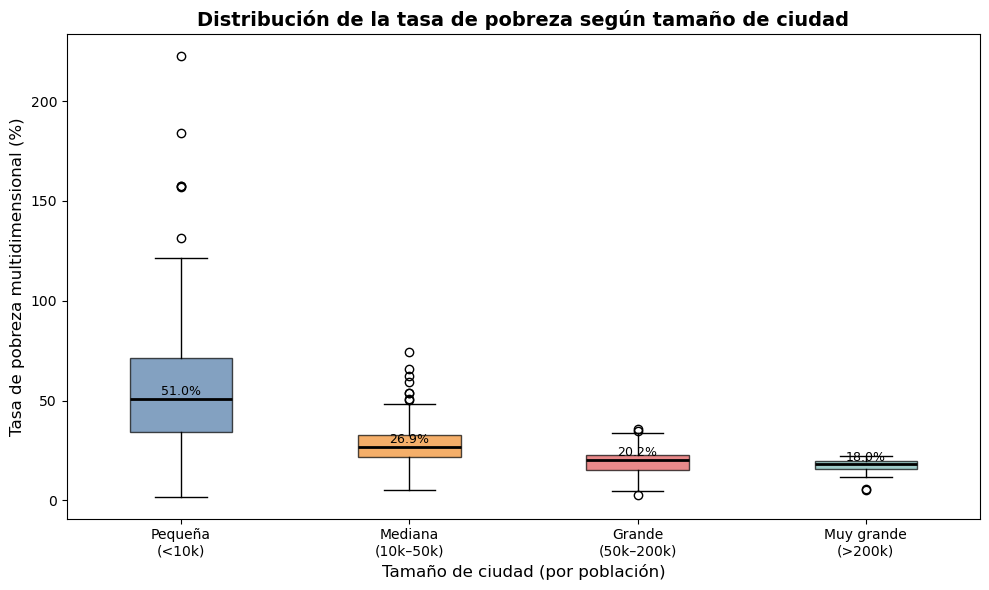

In [20]:
bins   = [0, 10_000, 50_000, 200_000, float('inf')]
labels = ['Pequeña\n(<10k)', 'Mediana\n(10k–50k)', 'Grande\n(50k–200k)', 'Muy grande\n(>200k)']
df['tamaño'] = pd.cut(df['poblacion_total'], bins=bins, labels=labels)

colores = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

fig, ax = plt.subplots(figsize=(10, 6))
grupos = [df[df['tamaño'] == t]['tasa_pobreza'].dropna() for t in labels]
bp = ax.boxplot(grupos, labels=labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Tamaño de ciudad (por población)', fontsize=12)
ax.set_ylabel('Tasa de pobreza multidimensional (%)', fontsize=12)
ax.set_title('Distribución de la tasa de pobreza según tamaño de ciudad', fontsize=14, fontweight='bold')

# Anotar mediana en cada caja
for i, grupo in enumerate(grupos, 1):
    mediana = grupo.median()
    ax.text(i, mediana + 0.3, f'{mediana:.1f}%', ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('boxplot_tamaño_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

## Gráfico 3 — Top 10 comunas con mayor y menor tasa de pobreza

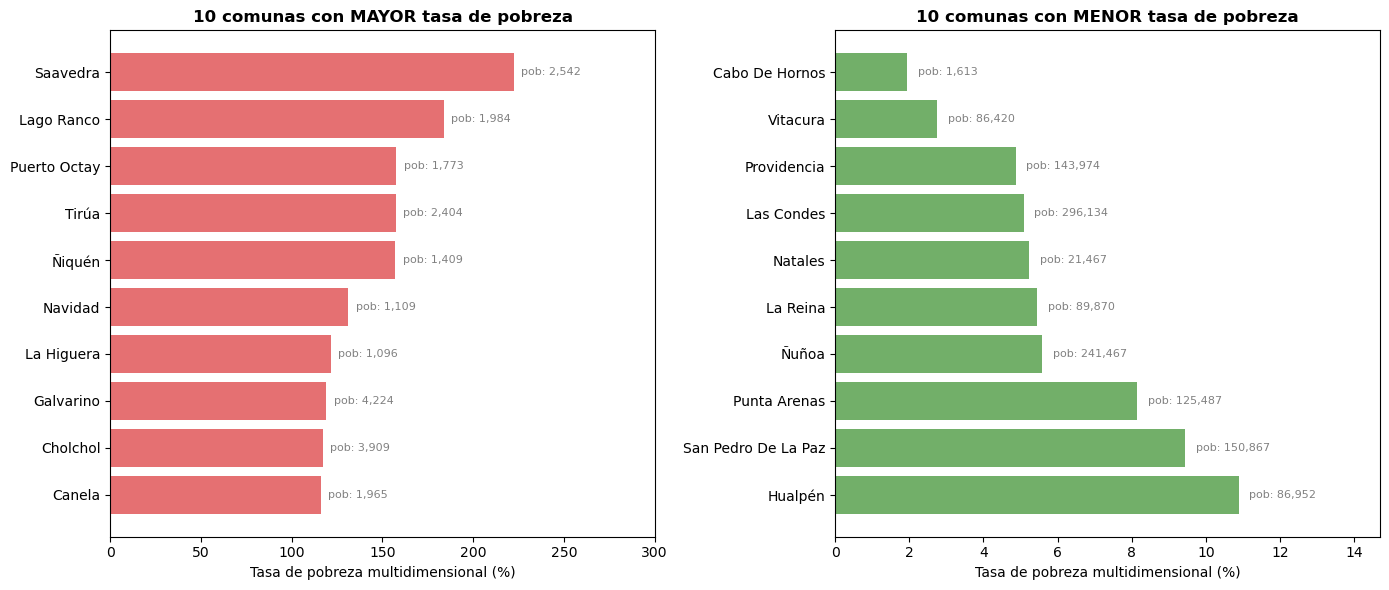

In [21]:
top10    = df.nlargest(10, 'tasa_pobreza').sort_values('tasa_pobreza')
bottom10 = df.nsmallest(10, 'tasa_pobreza').sort_values('tasa_pobreza', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mayor tasa
bars0 = axes[0].barh(top10.index.str.title(), top10['tasa_pobreza'], color='#e15759', alpha=0.85)
for bar, pob in zip(bars0, top10['poblacion_total']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'  pob: {pob:,.0f}', va='center', fontsize=8, color='gray')
axes[0].set_title('10 comunas con MAYOR tasa de pobreza', fontweight='bold')
axes[0].set_xlabel('Tasa de pobreza multidimensional (%)')
axes[0].set_xlim(0, top10['tasa_pobreza'].max() * 1.35)

# Menor tasa
bars1 = axes[1].barh(bottom10.index.str.title(), bottom10['tasa_pobreza'], color='#59a14f', alpha=0.85)
for bar, pob in zip(bars1, bottom10['poblacion_total']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'  pob: {pob:,.0f}', va='center', fontsize=8, color='gray')
axes[1].set_title('10 comunas con MENOR tasa de pobreza', fontweight='bold')
axes[1].set_xlabel('Tasa de pobreza multidimensional (%)')
axes[1].set_xlim(0, bottom10['tasa_pobreza'].max() * 1.35)

plt.tight_layout()
plt.savefig('barras_top10_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlación y conclusión

In [22]:
corr_abs  = df['poblacion_total'].corr(df['pobreza_multidimensional'])
corr_tasa = df['poblacion_total'].corr(df['tasa_pobreza'])

print(f"Correlación población ↔ pobreza absoluta : {corr_abs:.4f}")
print(f"Correlación población ↔ tasa de pobreza  : {corr_tasa:.4f}")
print()
print("Tasa de pobreza media por tamaño de ciudad:")
print(df.groupby('tamaño', observed=True)['tasa_pobreza'].agg(['median', 'mean']).rename(
    columns={'median': 'mediana (%)', 'mean': 'promedio (%)'}).round(2))

Correlación población ↔ pobreza absoluta : 0.9384
Correlación población ↔ tasa de pobreza  : -0.3571

Tasa de pobreza media por tamaño de ciudad:
                     mediana (%)  promedio (%)
tamaño                                        
Pequeña\n(<10k)            51.01         57.45
Mediana\n(10k–50k)         26.90         28.93
Grande\n(50k–200k)         20.20         19.54
Muy grande\n(>200k)        18.01         16.75
